<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1> Módulo 1: Crear una Red Neuronal Convolucional con TensorFlow</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>

## Importar las librerías necesarias

En este notebook construiremos un clasificador de imágenes **binario** (caballo vs. humano) con una **red neuronal convolucional (CNN)** en TensorFlow 2 / Keras. Usaremos APIs modernas: `image_dataset_from_directory` para los datos, capas de **aumento de datos** y **normalización** dentro del modelo, y **BatchNormalization** + **Dropout** para regularizar.


In [1]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Descargar y preparar el dataset (Horses or Humans)

Usaremos el dataset **Horses or Humans**: imágenes de $300\times300$ píxeles a color de caballos y humanos generados por computadora. Construiremos un clasificador que, dada una imagen, determine si contiene un **caballo** o un **humano**.

La siguiente celda **descarga** los conjuntos de entrenamiento y validación (solo la primera vez) y los descomprime en una carpeta local `data/`. Cada conjunto contiene subcarpetas `horses/` y `humans/`; más adelante, `image_dataset_from_directory` **etiquetará automáticamente** las imágenes a partir del nombre de la subcarpeta.


In [2]:
# Descargar y descomprimir el dataset en una carpeta local 'data/' (multiplataforma)
os.makedirs('data', exist_ok=True)

datasets = {
    'horse-or-human':            'https://storage.googleapis.com/learning-datasets/horse-or-human.zip',
    'validation-horse-or-human': 'https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip',
}

for nombre, url in datasets.items():
    out_dir = os.path.join('data', nombre)
    if not os.path.isdir(out_dir):
        zip_path = os.path.join('data', nombre + '.zip')
        if not os.path.exists(zip_path):
            print(f'Descargando {nombre} ...')
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
        print(f'  -> extraído en {out_dir}')
    else:
        print(f'{nombre} ya está disponible.')


horse-or-human ya está disponible.
validation-horse-or-human ya está disponible.


In [3]:
train_dir = os.path.join('data', 'horse-or-human')
val_dir   = os.path.join('data', 'validation-horse-or-human')

## Explorar los datos

El dataset está organizado en carpetas: el conjunto de **entrenamiento** contiene las subcarpetas `horses/` y `humans/`, y lo mismo el de **validación**. 

Una particularidad importante: **no etiquetamos las imágenes manualmente**. A diferencia de MNIST o Fashion-MNIST (donde las etiquetas venían dadas), aquí la etiqueta se deduce del **nombre de la subcarpeta** en la que está cada imagen. La utilidad `image_dataset_from_directory` se encarga de leer las imágenes y asignarles la clase automáticamente.

Definamos las rutas a cada subdirectorio:


In [4]:
# Rutas a los subdirectorios de cada clase
train_horse_dir = os.path.join(train_dir, 'horses')
train_human_dir = os.path.join(train_dir, 'humans')
validation_horse_dir = os.path.join(val_dir, 'horses')
validation_human_dir = os.path.join(val_dir, 'humans')

In [5]:
validation_human_dir

'data\\validation-horse-or-human\\humans'

In [6]:
train_human_dir

'data\\horse-or-human\\humans'

Ahora, veamos cómo se ven los nombres de los archivos en los directorios de entrenamiento de caballos y humanos:

In [7]:
train_horse_names = os.listdir(train_horse_dir)
print(train_horse_names[:10])

['horse01-0.png', 'horse01-1.png', 'horse01-2.png', 'horse01-3.png', 'horse01-4.png', 'horse01-5.png', 'horse01-6.png', 'horse01-7.png', 'horse01-8.png', 'horse01-9.png']


In [8]:
train_horse_names

['horse01-0.png',
 'horse01-1.png',
 'horse01-2.png',
 'horse01-3.png',
 'horse01-4.png',
 'horse01-5.png',
 'horse01-6.png',
 'horse01-7.png',
 'horse01-8.png',
 'horse01-9.png',
 'horse02-0.png',
 'horse02-1.png',
 'horse02-2.png',
 'horse02-3.png',
 'horse02-4.png',
 'horse02-5.png',
 'horse02-6.png',
 'horse02-7.png',
 'horse02-8.png',
 'horse02-9.png',
 'horse03-0.png',
 'horse03-1.png',
 'horse03-2.png',
 'horse03-3.png',
 'horse03-4.png',
 'horse03-5.png',
 'horse03-6.png',
 'horse03-7.png',
 'horse03-8.png',
 'horse03-9.png',
 'horse04-0.png',
 'horse04-1.png',
 'horse04-2.png',
 'horse04-3.png',
 'horse04-4.png',
 'horse04-5.png',
 'horse04-6.png',
 'horse04-7.png',
 'horse04-8.png',
 'horse04-9.png',
 'horse05-0.png',
 'horse05-1.png',
 'horse05-2.png',
 'horse05-3.png',
 'horse05-4.png',
 'horse05-5.png',
 'horse05-6.png',
 'horse05-7.png',
 'horse05-8.png',
 'horse05-9.png',
 'horse06-0.png',
 'horse06-1.png',
 'horse06-2.png',
 'horse06-3.png',
 'horse06-4.png',
 'horse06-

In [9]:
train_humans_names = os.listdir(train_human_dir)
print(train_humans_names[:10])

['human01-00.png', 'human01-01.png', 'human01-02.png', 'human01-03.png', 'human01-04.png', 'human01-05.png', 'human01-06.png', 'human01-07.png', 'human01-08.png', 'human01-09.png']


Averigüemos el número total de imágenes de caballos y humanos en los directorios:

In [10]:
len(train_humans_names), len(train_horse_names)

(527, 500)

Ahora echemos un vistazo a algunas imágenes para tener una mejor idea de cómo se ven. Primero, configure los parámetros de matplot:

In [11]:
nrows= 4
ncols = 4
pic_index=0

Now, display a batch of 8 horse and 8 human pictures. You can rerun the cell to see a fresh batch each time:

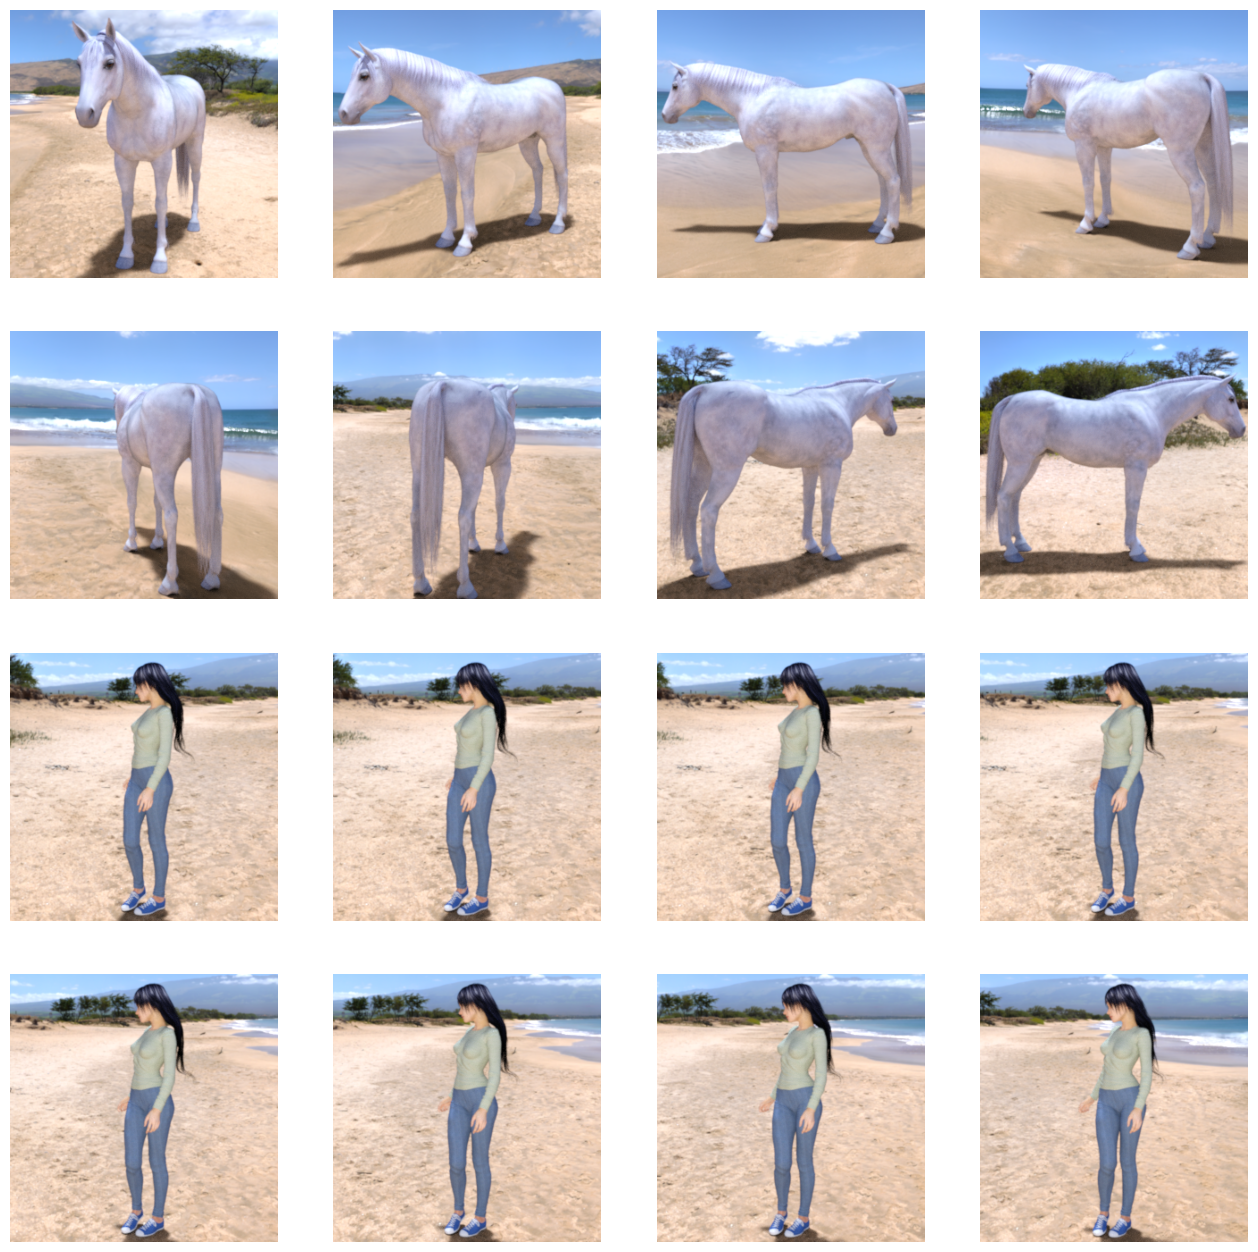

In [12]:
fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)

pic_index +=8
next_horse_pix = [os.path.join(train_horse_dir, fname) for fname in train_horse_names[pic_index -8 : pic_index]]
next_human_pix = [os.path.join(train_human_dir, fname) for fname in train_humans_names[pic_index -8 : pic_index]]

for i, img_path in enumerate(next_horse_pix+next_human_pix):
    sp=plt.subplot(nrows,ncols, i+1)
    sp.axis('off')
    
    img = mpimg.imread(img_path)
    plt.imshow(img)
    
plt.show()


In [13]:
img.shape

(300, 300, 4)

## Preparar los datos con `image_dataset_from_directory`

En lugar del antiguo `ImageDataGenerator` (obsoleto), usamos **`tf.keras.utils.image_dataset_from_directory`**, que crea un `tf.data.Dataset` eficiente leyendo las imágenes de las carpetas y etiquetándolas por subcarpeta.

- Redimensionamos a $150\times150$ (más rápido que $300\times300$ y suficiente para este problema).
- `label_mode='binary'` porque son 2 clases.
- Aplicamos `cache()` y `prefetch()` para acelerar el entrenamiento.

> La **normalización** de los píxeles a $[0,1]$ la haremos con una capa `Rescaling` **dentro del modelo**, así el mismo preprocesamiento se aplica automáticamente en entrenamiento e inferencia.


In [14]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size = BATCH_SIZE, label_mode = 'binary', seed=42)
val_ds = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size = BATCH_SIZE, label_mode = 'binary', seed=42)

class_name = train_ds.class_names
print('Clases: ', class_name)


Found 1027 files belonging to 2 classes.
Found 256 files belonging to 2 classes.
Clases:  ['horses', 'humans']


In [15]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [16]:
# Optimización del pipeline: cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

## Construir la red neuronal convolucional

### Definir el modelo

Nuestra CNN apila varios bloques de **`Conv2D` → `BatchNormalization` → `MaxPooling2D`**, que extraen características cada vez más complejas mientras reducen el tamaño espacial. Mejoras respecto al modelo original:

- **Aumento de datos** (`RandomFlip`, `RandomRotation`, `RandomZoom`) al inicio: genera variaciones de las imágenes en cada época para **reducir el sobreajuste** (solo actúa durante el entrenamiento).
- **`Rescaling(1./255)`**: normaliza los píxeles a $[0,1]$ dentro del modelo.
- **`BatchNormalization`**: estabiliza y acelera el entrenamiento.
- **`Dropout`**: regularización adicional antes de la capa densa.

Como es un problema de clasificación **binaria**, la red termina con **una** neurona y activación **sigmoide**, cuya salida es la probabilidad (entre 0 y 1) de pertenecer a la clase 1.


In [17]:
# Bloque de aumento de datos (solo se aplica durante el entrenamiento)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')

# Crear la arquitectura de la red, model
model = tf.keras.models.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2), 

    layers.Conv2D(32, (3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2), 

    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2), 

    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2), 

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
    
])

In [18]:
# resumen de la arquitectura
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 148, 148, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 15, 15, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,606,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,667,873 (6.36 MB)

 Trainable params: 1,667,521 (6.36 MB)

 Non-trainable params: 352 (1.38 KB)

La columna "forma de salida" muestra cómo evoluciona el tamaño de su mapa de características en cada capa sucesiva. Las capas de convolución reducen un poco el tamaño de los mapas de características debido al relleno, y cada capa de agrupación reduce a la mitad las dimensiones.

A continuación, configuraremos las especificaciones para el entrenamiento del modelo. Entrenaremos nuestro modelo con la pérdida de entropía cruzada binaria, porque es un problema de clasificación binaria y nuestra activación final es un sigmoide. (Para refrescar las métricas de pérdida, consulte el Curso intensivo de aprendizaje automático). Usaremos el optimizador rmsprop con una tasa de aprendizaje de 0,001. Durante el entrenamiento, querremos monitorear la precisión de la clasificación.

NOTA: En este caso, usar el algoritmo de optimización RMSprop es preferible al descenso de gradiente estocástico (SGD), porque RMSprop automatiza el ajuste de la tasa de aprendizaje para nosotros. (Otros optimizadores, como Adam y Adagrad, también adaptan automáticamente la tasa de aprendizaje durante el entrenamiento y funcionarían igual de bien aquí).

### Compilar el modelo



In [19]:
# RMSprop adapta la tasa de aprendizaje automáticamente (Adam funcionaría igual de bien)
model.compile(loss='binary_crossentropy', optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001), metrics=['accuracy'])


### Entrenar el modelo

Entrenamos durante 15 épocas usando los `tf.data.Dataset` que preparamos. Guardamos el `history` para graficar las curvas de aprendizaje. En CPU puede tardar varios minutos.

In [20]:
# Guardar el historial del loss
history = model.fit(train_ds, validation_data = val_ds, epochs=15, verbose=1)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.8423 - loss: 1.0169 - val_accuracy: 0.7500 - val_loss: 0.4831
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.9357 - loss: 0.2029 - val_accuracy: 0.5039 - val_loss: 1.5594
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.9357 - loss: 0.1808 - val_accuracy: 0.5000 - val_loss: 2.3534
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.9572 - loss: 0.1499 - val_accuracy: 0.8594 - val_loss: 0.3470
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.9630 - loss: 0.1386 - val_accuracy: 0.7305 - val_loss: 1.0449
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.9747 - loss: 0.0843 - val_accuracy: 0.8320 - val_loss: 0.4653
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.9786 - loss: 0.0855 - val_accuracy: 0.7969 - val_loss: 0.3649
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.9805 - loss: 0.0711 - val_accuracy: 0.

### Curvas de aprendizaje

Graficamos la pérdida y la precisión de entrenamiento frente a las de validación para diagnosticar el aprendizaje (y detectar sobreajuste).

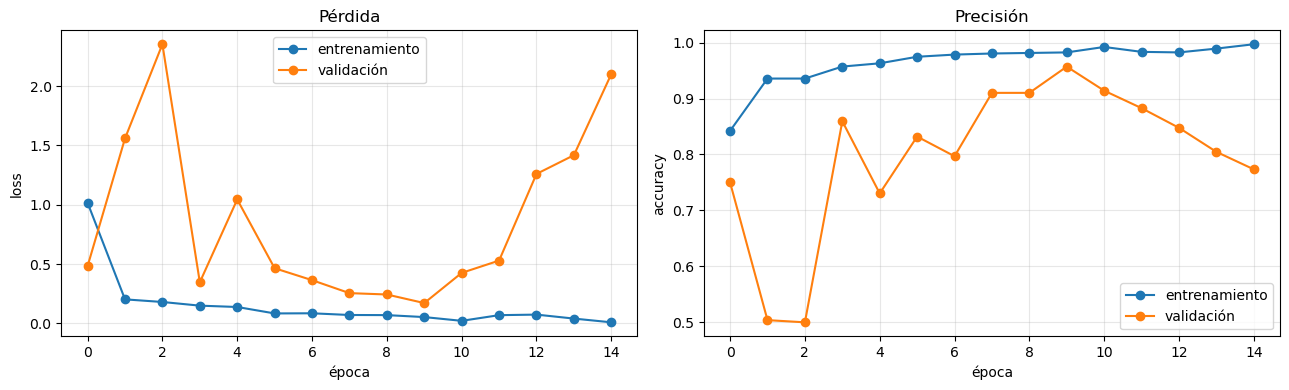

In [21]:
h = history.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(h['loss'], marker='o', label='entrenamiento')
ax1.plot(h['val_loss'], marker='o', label='validación')
ax1.set_title('Pérdida'); ax1.set_xlabel('época'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(h['accuracy'], marker='o', label='entrenamiento')
ax2.plot(h['val_accuracy'], marker='o', label='validación')
ax2.set_title('Precisión'); ax2.set_xlabel('época'); ax2.set_ylabel('accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluar el modelo y hacer predicciones

Primero medimos la precisión sobre el conjunto de **validación** completo. Luego mostramos predicciones sobre imágenes concretas: recuerda que la salida es una probabilidad; si es **mayor que 0.5** la clase predicha es la 1 (`humans`), y si no, la clase 0 (`horses`).

In [22]:
# Precisión sobre todo el conjunto de validación
val_loss, val_acc = model.evaluate(val_ds, verbose=0)

In [23]:
val_loss, val_acc

(2.1022510528564453, 0.7734375)

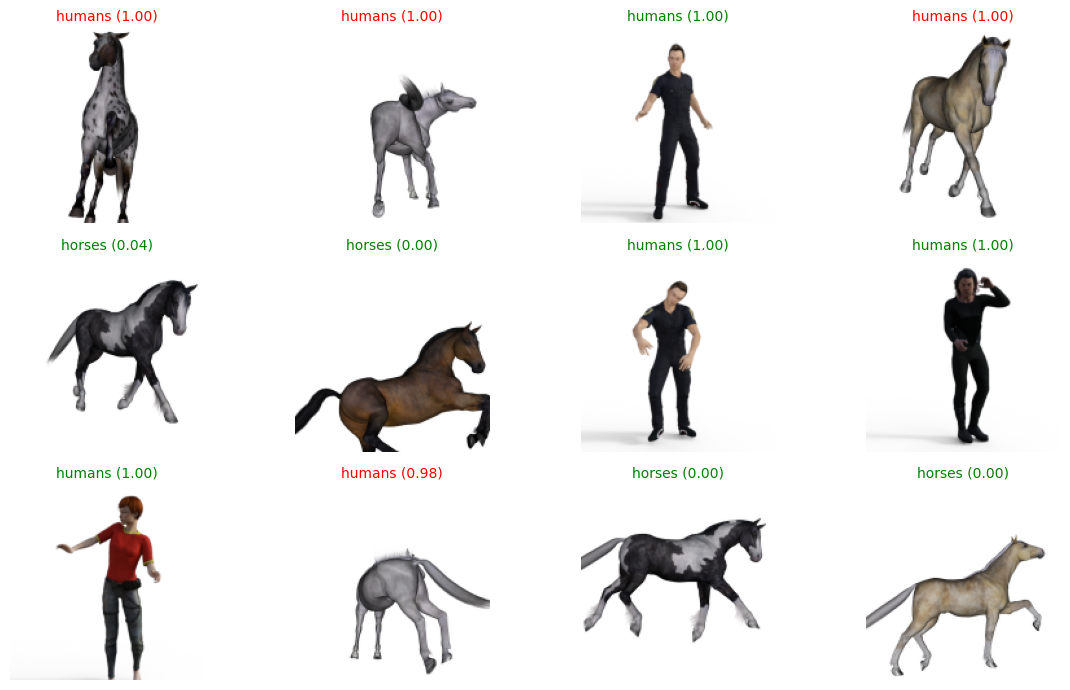

In [25]:
# Predicciones sobre un lote de validación (verde = acierto, rojo = error)
images, labels = next(iter(val_ds))
probs = model.predict(images, verbose=0).ravel()
preds = (probs > 0.5).astype(int)
reales = labels.numpy().ravel().astype(int)

plt.figure(figsize=(12, 7))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    correcto = preds[i] == reales[i]
    color = 'green' if correcto else 'red'
    plt.title(f'{class_name[preds[i]]} ({probs[i]:.2f})', color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()